# Clasificación de alta letalidad en siniestros viales fatales del Perú

**Red neuronal para clasificación retrospectiva de multifatalidad (ONSV 2021–2025)**

- **Autores:** Rendo Alfonte Tarqui; Yimmy Yeyson Cuyo Zamata
- **Curso:** Redes Neuronales — Segunda Unidad
- **Repositorio:** <https://github.com/ForLess01/Accident_NN>

El problema es de **clasificación binaria condicional**: dado un siniestro ya fatal, la red estima si registró un fallecido (clase 0) o dos o más fallecidos (clase 1, *multifatal*). El modelo no estima la probabilidad de que un siniestro cualquiera sea mortal.

El recorrido abarca la verificación de las fuentes, el análisis exploratorio, la partición cronológica, la ingeniería de características, la arquitectura, el entrenamiento, la calibración, la evaluación y la explicabilidad. La limpieza inicial que produce `data/processed/base_limpia.parquet` a partir de los libros oficiales se ejecuta con los scripts de `src/`; aquí se parte de su resultado.

In [1]:
import sys
from pathlib import Path

REPOSITORIO = "https://github.com/ForLess01/Accident_NN.git"

# En Google Colab el proyecto no está presente: se obtiene del repositorio.
if "google.colab" in sys.modules and not Path("src").is_dir():
    import shutil
    import subprocess
    import tempfile

    descarga = Path(tempfile.mkdtemp())
    subprocess.run(["git", "clone", "--depth", "1", REPOSITORIO, str(descarga)],
                   check=True, capture_output=True)
    for elemento in descarga.iterdir():
        destino = Path.cwd() / elemento.name
        if elemento.name != ".git" and not destino.exists():
            shutil.move(str(elemento), str(destino))
    shutil.rmtree(descarga, ignore_errors=True)

CANDIDATOS = (Path.cwd(), *Path.cwd().parents)
ROOT = next((ruta for ruta in CANDIDATOS if (ruta / "src").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz del proyecto: ninguna carpeta contiene 'src/'. "
        f"Directorio actual: {Path.cwd()}"
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

## 1. Verificación de fuentes oficiales

Las cuatro fuentes utilizadas (SINIESTROS, VEHICULOS, PERSONAS y el diccionario de datos) están declaradas en `data/raw/source_manifest.json` con su URL de origen, tamaño y SHA-256. La verificación se ejecuta antes de cualquier lectura: un archivo faltante, adicional o modificado detiene el proceso.

In [2]:
import pandas as pd

from src.source_provenance import verify_raw_sources

verificacion = verify_raw_sources()
assert verificacion["source_count"] == 4
pd.DataFrame(verificacion["verified_sources"])

,path,bytes,sha256
0,BBDD_ONSV_PERSONAS_2021-2025.xlsx,4203578,6bd03aa2b8918147f31d69c0be031d7011aa5e0df840bf...
1,BBDD_ONSV_SINIESTROS_FATALES_2021-2025.xlsx,1519015,4b815b6823cd558d55c8343ca0ab13023cbd63ef162c1c...
2,BBDD_ONSV_VEHICULOS_2021-2025.xlsx,1763791,4335dbcdcf9dc0d46acd81723b64765fd65a58a1515793...
3,Formato_2_Diccionario_de_datos.docx,14887,b1160523694486bb093e99ea083c8d32159d3177745b06...


## 2. Prueba ejecutable del proxy PERSONAS

La tabla PERSONAS no se usa como entrada del modelo. La auditoría por código demuestra que, en los 9 104 siniestros, el conteo de personas con `GRAVEDAD = FALLECIDO` coincide con `FALLECIDOS` y reconstruye la variable objetivo. Como el objetivo es `FALLECIDOS >= 2`, cualquier agregado derivado de esa tabla está estructuralmente contaminado; la decisión metodológica excluye la fuente completa de los predictores.

In [3]:
import json

prueba = json.loads(
    (ROOT / "report/tables/personas_target_proxy_identity.json").read_text()
)
assert prueba["personas_used_for_modeling"] is False
assert prueba["all_targets_reconstructed"] is True
pd.DataFrame([prueba]).T.rename(columns={0: "valor"})

,valor
schema_version,1
purpose,executable target-proxy lineage proof; PERSONA...
rows,9104
deceased_count_identity_rows,9104
person_rows_cover_deceased_rows,9104
target_identity_rows,9104
all_deceased_counts_equal_fallecidos,True
all_person_counts_cover_fallecidos,True
all_targets_reconstructed,True
decision,exclude every PERSONAS-derived aggregate from ...


## 3. Universo de estudio y variable objetivo

El dataset limpio contiene 9 104 siniestros fatales registrados entre 2021 y 2025 (2024–2025 preliminar). La tasa multifatal anual es condicional a siniestros ya fatales y se mantiene estable alrededor del 10 %.

In [4]:
base = pd.read_parquet(ROOT / "data/processed/base_limpia.parquet")
base["FECHA"] = pd.to_datetime(base["FECHA"])
base["anio"] = base["FECHA"].dt.year

resumen_anual = (
    base.groupby("anio")["target_multifatal"]
    .agg(registros="size", multifatales="sum")
    .assign(tasa_pct=lambda t: (100 * t["multifatales"] / t["registros"]).round(2))
)
assert len(base) == 9104
resumen_anual

,registros,multifatales,tasa_pct
anio,,,
2021,2392,232,9.70
2022,2480,278,11.21
2023,2000,196,9.80
2024,1554,151,9.72
2025,678,71,10.47


## 4. Análisis exploratorio de datos

El análisis completo produce catorce figuras y once hallazgos numerados, generados por `src/block_c_eda.py`. Se reproducen aquí los tres que más condicionaron las decisiones de modelado.

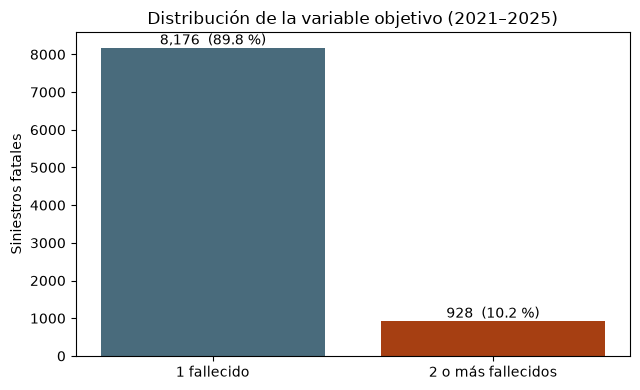

In [5]:
import matplotlib.pyplot as plt

COLOR_BASE, COLOR_ACENTO = "#496B7C", "#A63F12"

conteo = base["target_multifatal"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(["1 fallecido", "2 o más fallecidos"], conteo.values,
       color=[COLOR_BASE, COLOR_ACENTO])
for i, v in enumerate(conteo.values):
    ax.text(i, v, f"{v:,}  ({100 * v / len(base):.1f} %)",
            ha="center", va="bottom")
ax.set_ylabel("Siniestros fatales")
ax.set_title("Distribución de la variable objetivo (2021–2025)")
plt.tight_layout()
plt.show()

La clase multifatal representa el 10.2 % del universo. El desbalance justifica el uso de pesos de clase durante el entrenamiento y la evaluación con PR-AUC, F1, precisión y recall de la clase minoritaria; la *accuracy* aislada no es informativa.

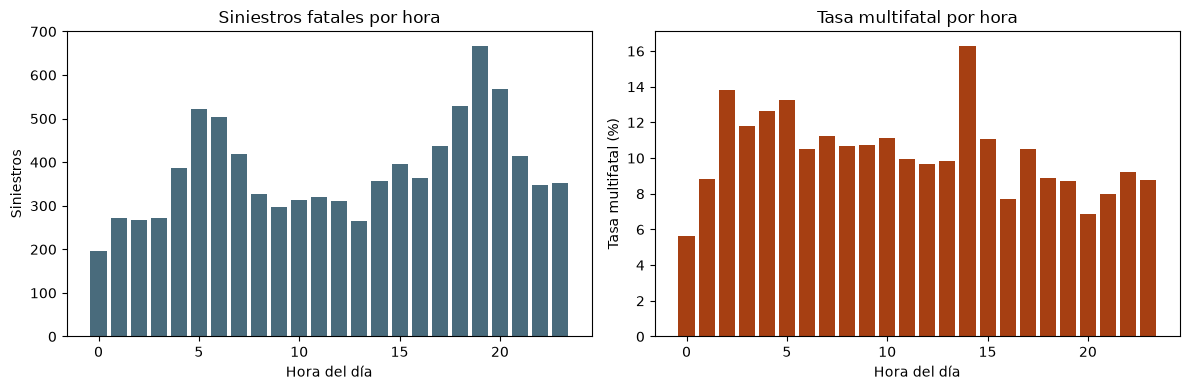

In [6]:
por_hora = (
    base.dropna(subset=["hora_entera"])
    .groupby("hora_entera")["target_multifatal"]
    .agg(registros="size", tasa="mean")
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(por_hora.index, por_hora["registros"], color=COLOR_BASE)
axes[0].set_title("Siniestros fatales por hora")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Siniestros")
axes[1].bar(por_hora.index, 100 * por_hora["tasa"], color=COLOR_ACENTO)
axes[1].set_title("Tasa multifatal por hora")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Tasa multifatal (%)")
plt.tight_layout()
plt.show()

El volumen y la letalidad no coinciden: la hora con más siniestros es las 19:00, mientras que la mayor tasa multifatal (16.3 %) ocurre a las 14:00. Por eso la hora entra al modelo como codificación cíclica y franja horaria, no como conteo.

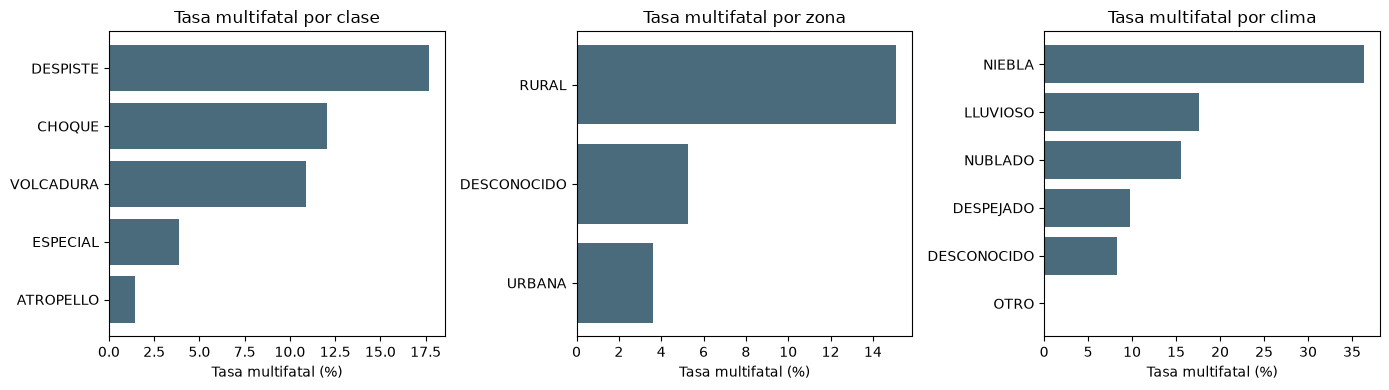

In [7]:
from src.features import normalize_clase, normalize_clima, normalize_zona

condiciones = pd.DataFrame({
    "CLASE": base["CLASE"].apply(normalize_clase),
    "ZONA": base["ZONA"].apply(normalize_zona),
    "CLIMA": base["CLIMA"].apply(normalize_clima),
    "target": base["target_multifatal"],
})
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, columna in zip(axes, ["CLASE", "ZONA", "CLIMA"]):
    tasa = (100 * condiciones.groupby(columna)["target"].mean()).sort_values()
    ax.barh(tasa.index, tasa.values, color=COLOR_BASE)
    ax.set_title(f"Tasa multifatal por {columna.lower()}")
    ax.set_xlabel("Tasa multifatal (%)")
plt.tight_layout()
plt.show()

DESPISTE presenta la mayor tasa multifatal entre las clases (17.7 %) aunque CHOQUE sea la más frecuente. La zona rural cuadruplica la tasa urbana (15.1 % frente a 3.6 %) y la lluvia supera al clima despejado (17.6 % frente a 9.8 %). Las condiciones pre-impacto separan el riesgo y anticipan que la red dispone de señal estructural real.

## 5. Partición cronológica

El protocolo temporal está predeclarado: la arquitectura, la configuración y la semilla se eligen con ajuste en 2021 y comparación en 2022; el modelo final se reajusta una única vez en 2021–2022; la partición 2023 se reserva para validar calibración y umbrales; y 2024–2025 es una referencia histórica ya consultada que no autoriza reajustes.

In [8]:
from src.model_protocol import split_chronological

particiones = split_chronological(base)
resumen_particiones = pd.DataFrame([
    ("2021–2022", "Reajuste final (selección interna: ajuste 2021, comparación 2022)",
     particiones["y_train"]),
    ("2023", "Validación de calibración y umbrales", particiones["y_validation"]),
    ("2024–2025", "Referencia histórica ya consultada", particiones["y_test"]),
], columns=["periodo", "rol", "y"])
resumen_particiones["registros"] = resumen_particiones["y"].map(len)
resumen_particiones["multifatales"] = resumen_particiones["y"].map(lambda s: int(s.sum()))
resumen_particiones["tasa_pct"] = (
    100 * resumen_particiones["multifatales"] / resumen_particiones["registros"]
).round(2)
resumen_particiones.drop(columns="y")

,periodo,rol,registros,multifatales,tasa_pct
0,2021–2022,Reajuste final (selección interna: ajuste 2021...,4872,510,10.47
1,2023,Validación de calibración y umbrales,2000,196,9.80
2,2024–2025,Referencia histórica ya consultada,2232,222,9.95


## 6. Ingeniería de características: contrato sin PERSONAS

El preprocesador se ajusta exclusivamente con la partición de entrenamiento (2021–2022): normaliza categorías con clase `DESCONOCIDO`, estandariza variables continuas, codifica *one-hot*, representa cíclicamente mes, día de semana y hora, e incluye interacciones predeclaradas de contexto vial. El contrato resultante transforma 21 campos crudos en 169 columnas `float32` en orden fijo.

In [9]:
from src.model_protocol import (
    PERSONAS_DERIVED_COLUMNS,
    fit_preprocessor,
    transform_features,
)

scaler, encoders = fit_preprocessor(particiones["X_train_raw"])
X_train = transform_features(particiones["X_train_raw"], scaler, encoders)
X_val = transform_features(particiones["X_validation_raw"], scaler, encoders)
X_ref = transform_features(particiones["X_test_raw"], scaler, encoders)

assert X_train.shape[1] == 169
assert PERSONAS_DERIVED_COLUMNS.isdisjoint(X_train.columns)

PREFIJOS = [
    "road_type_zone", "road_network_class", "via_prefijo", "departamento",
    "region", "franja", "clase", "zona", "red_vial", "tipo_via", "clima",
    "caracteristica", "perfil", "superficie",
]

def familia(nombre: str) -> str:
    for prefijo in PREFIJOS:
        if nombre.startswith(prefijo + "_"):
            return f"one-hot: {prefijo}"
    return "continua / binaria / cíclica"

resumen_familias = (
    pd.Series([familia(c) for c in X_train.columns])
    .value_counts()
    .rename_axis("familia")
    .to_frame("características")
)
print(f"Matrices: entrenamiento {X_train.shape}, validación {X_val.shape}, "
      f"referencia {X_ref.shape}")
resumen_familias

Matrices: entrenamiento (4872, 169), validación (2000, 169), referencia (2232, 169)


,características
familia,
one-hot: road_network_class,30
one-hot: via_prefijo,26
one-hot: departamento,25
continua / binaria / cíclica,22
one-hot: road_type_zone,18
one-hot: clase,6
one-hot: tipo_via,6
one-hot: clima,6
one-hot: caracteristica,6


### Decisiones de disponibilidad

Cada familia de campos tiene una decisión documentada. Se excluyen los resultados posteriores al evento (fallecidos, lesionados, daños), las conclusiones de investigación, los campos con faltantes dependientes del periodo y todos los agregados PERSONAS. Los agregados VEHICULOS se admiten solo con alcance de clasificación histórica retrospectiva.

In [10]:
auditoria = pd.read_csv(ROOT / "report/tables/feature_availability_audit.csv")
personas_mask = auditoria["source_fields"].str.contains("PERSONAS")
assert (auditoria.loc[personas_mask, "decision"]
        == "exclude entire source from predictors").all()
auditoria

,source_fields,source_stage,timestamp_evidence,target_dependency,allowed_scope,decision
0,"FECHA, HORA",Consolidated registry,timestamp not supplied,not evaluated,retrospective historical classification,Calendar and cyclic-time features
1,"DEPARTAMENTO, coordenadas, red/tipo de vía",Consolidated registry,timestamp not supplied,not evaluated,retrospective historical classification,Location and road context
2,"ZONA, CLIMA, geometría, superficie",Consolidated registry,timestamp not supplied,not evaluated,retrospective historical classification,Scene and infrastructure context
3,CLASE,Consolidated registry,timestamp not supplied,no,retrospective historical classification,Retrospective classification
4,VEHICULOS involucrados (conteos y tipo),VEHICULOS companion registry,timestamp not supplied,not evaluated,retrospective historical classification,include with scope restriction
5,Todos los agregados de PERSONAS,PERSONAS companion registry,not usable: cardinality/deceased counts encode...,yes,none,exclude entire source from predictors
6,"FALLECIDOS, LESIONADOS, VEHICULOS_DANADOS",Outcome/count after event,no,no,retrospective historical classification,Excluded: direct outcome leakage
7,"CAUSA_FACTOR, CAUSA_ESPECIFICA",Investigation conclusion,no,no,retrospective historical classification,Excluded: post-investigation leakage
8,"SENAL_VERTICAL, SENAL_HORIZONTAL",Sparse recording field,not reliable,not reliable,retrospective historical classification,Excluded: missingness is period-dependent


## 7. Arquitectura de la red neuronal

La red canónica es un perceptrón multicapa compacto:

$$169 \rightarrow \operatorname{Dense}(64, \mathrm{ReLU}) \rightarrow \operatorname{Dropout}(0.35) \rightarrow \operatorname{Dense}(32, \mathrm{ReLU}) \rightarrow \operatorname{Dropout}(0.35) \rightarrow \operatorname{Dense}(1, \sigma)$$

con regularización L2 de $3\times10^{-4}$ en los kernels ocultos, optimizador Adam con tasa inicial $5\times10^{-4}$ y lote de 64. Los parámetros entrenables son $(169+1)\cdot64 + (64+1)\cdot32 + (32+1)\cdot1 = 12\,993$.

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

L2 = 3e-4
DROPOUT = 0.35
TASA_APRENDIZAJE = 5e-4
LOTE = 64

def construir_mlp(n_entradas: int) -> keras.Model:
    modelo = keras.Sequential([
        layers.Input(shape=(n_entradas,)),
        layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(L2)),
        layers.Dropout(DROPOUT),
        layers.Dense(32, activation="relu",
                     kernel_regularizer=regularizers.l2(L2)),
        layers.Dropout(DROPOUT),
        layers.Dense(1, activation="sigmoid"),
    ])
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=TASA_APRENDIZAJE),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(curve="PR", name="pr_auc")],
    )
    return modelo

modelo = construir_mlp(X_train.shape[1])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,993 (50.75 KB)

 Trainable params: 12,993 (50.75 KB)

 Non-trainable params: 0 (0.00 B)

### Evidencia de la selección de configuración

La búsqueda comparó tres configuraciones completas (capas, dropout, L2 y tasa de aprendizaje) por tres semillas, con ajuste en 2021 y comparación en 2022, usando *early stopping* y `ReduceLROnPlateau` sobre PR-AUC. La regla, fijada antes de entrenar, elige la mayor mediana de PR-AUC entre semillas, con desempates por mediana de F1 y menor IQR, y conserva la corrida mediana en lugar de la mejor. El resultado es `MLP_64_32` con semilla 42 y 14 épocas para el reajuste.

In [12]:
grilla = pd.read_csv(ROOT / "report/tables/model_selection_seed_grid_validation.csv")
robustez = pd.read_csv(ROOT / "report/tables/model_selection_robustness.csv")
print("Agregación por configuración (regla de selección):")
display(robustez.round(4))
print("Detalle de las 9 corridas (3 configuraciones x 3 semillas):")
grilla.round(4)

Agregación por configuración (regla de selección):


,config_id,median_val_pr_auc,median_val_f1,pr_auc_iqr
0,MLP_64_32,0.3859,0.4269,0.0123
1,MLP_32_16,0.3746,0.4171,0.0149
2,MLP_32,0.3714,0.4139,0.0088


Detalle de las 9 corridas (3 configuraciones x 3 semillas):


,config_id,seed,hidden_units,dropout,l2,learning_rate,batch_size,epochs_ran,best_epoch,best_val_pr_auc_history,selected_threshold,f1_multifatal,precision_multifatal,recall_multifatal,pr_auc,roc_auc
0,MLP_32_16,42,32-16,0.25,0.0001,0.0010,64,32,12,0.3843,0.60,0.4171,0.3110,0.6331,0.3848,0.8202
1,MLP_32_16,314,32-16,0.25,0.0001,0.0010,64,32,12,0.3536,0.55,0.4129,0.3089,0.6223,0.3549,0.8182
2,MLP_32_16,2718,32-16,0.25,0.0001,0.0010,64,34,14,0.3722,0.60,0.4269,0.3151,0.6619,0.3746,0.8205
3,MLP_64_32,42,64-32,0.35,0.0003,0.0005,64,34,14,0.3848,0.60,0.4198,0.3123,0.6403,0.3859,0.8227
4,MLP_64_32,314,64-32,0.35,0.0003,0.0005,64,34,14,0.3913,0.60,0.4269,0.3301,0.6043,0.3922,0.8277
5,MLP_64_32,2718,64-32,0.35,0.0003,0.0005,64,41,21,0.3674,0.65,0.4277,0.3258,0.6223,0.3676,0.8185
6,MLP_32,42,32,0.20,0.0001,0.0005,64,57,37,0.3768,0.60,0.4355,0.3290,0.6439,0.3781,0.8217
7,MLP_32,314,32,0.20,0.0001,0.0005,64,40,20,0.3714,0.65,0.4139,0.3462,0.5144,0.3714,0.8148
8,MLP_32,2718,32,0.20,0.0001,0.0005,64,46,26,0.3599,0.65,0.4098,0.3422,0.5108,0.3606,0.8127


## 8. Entrenamiento: reajuste final en 2021–2022

Con la configuración y la semilla ya fijadas, el modelo se reajusta una única vez sobre todo 2021–2022 durante las 14 épocas determinadas por la selección interna, con pesos de clase balanceados. El modelo entregado es `models/final/model.keras`; la celda siguiente repite su entrenamiento para mostrar la evolución de la pérdida época a época.

In [13]:
from sklearn.utils.class_weight import compute_class_weight

SEMILLA = 42
EPOCAS_FIJAS = 14

y_train = particiones["y_train"].astype(int)
tf.keras.utils.set_random_seed(SEMILLA)
modelo = construir_mlp(X_train.shape[1])

pesos = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
pesos_clase = {0: float(pesos[0]), 1: float(pesos[1])}
print(f"Pesos de clase balanceados: {pesos_clase}")

historia = modelo.fit(
    X_train, y_train,
    epochs=EPOCAS_FIJAS,
    batch_size=LOTE,
    class_weight=pesos_clase,
    verbose=2,
)

Pesos de clase balanceados: {0: 0.5584594222833562, 1: 4.776470588235294}
Epoch 1/14


77/77 - 0s - 6ms/step - loss: 0.7117 - pr_auc: 0.1730


Epoch 2/14


77/77 - 0s - 536us/step - loss: 0.6476 - pr_auc: 0.2401


Epoch 3/14


...

77/77 - 0s - 431us/step - loss: 0.5335 - pr_auc: 0.3603


Epoch 13/14


77/77 - 0s - 428us/step - loss: 0.5295 - pr_auc: 0.3725


Epoch 14/14


77/77 - 0s - 475us/step - loss: 0.5160 - pr_auc: 0.3756


### Curvas de aprendizaje

La curva izquierda corresponde a la corrida seleccionada durante la búsqueda (ajuste 2021 frente a comparación 2022) con PR-AUC no ponderada en ambas particiones, por lo que las series son directamente comparables. La curva derecha muestra la pérdida del reajuste final; por diseño, el reajuste no usa *callbacks* de validación.

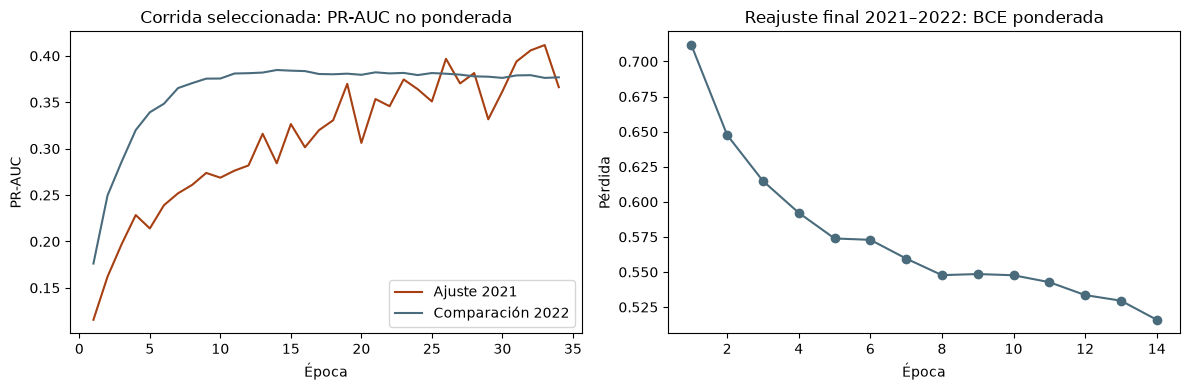

In [14]:
curvas = pd.read_csv(ROOT / "report/tables/model_learning_curves.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(curvas["epoch"], curvas["train_pr_auc_unweighted"],
             color=COLOR_ACENTO, label="Ajuste 2021")
axes[0].plot(curvas["epoch"], curvas["validation_pr_auc_unweighted"],
             color=COLOR_BASE, label="Comparación 2022")
axes[0].set_title("Corrida seleccionada: PR-AUC no ponderada")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("PR-AUC")
axes[0].legend()
axes[1].plot(range(1, EPOCAS_FIJAS + 1), historia.history["loss"],
             color=COLOR_BASE, marker="o")
axes[1].set_title("Reajuste final 2021–2022: BCE ponderada")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
plt.tight_layout()
plt.show()

### Brecha de generalización

La brecha se mide con la misma métrica no ponderada en ambas particiones. La tabla contrasta el modelo recién reajustado con el modelo entregado; cualquier diferencia numérica provendría del carácter no determinista del entrenamiento en hardware distinto.

In [15]:
from sklearn.metrics import average_precision_score, brier_score_loss

brecha = json.loads(
    (ROOT / "report/tables/model_generalization_gap.json").read_text()
)
y_val = particiones["y_validation"].astype(int)
p_val = modelo.predict(X_val, verbose=0).reshape(-1)
p_train = modelo.predict(X_train, verbose=0).reshape(-1)

comparacion = pd.DataFrame(
    {
        "PR-AUC entrenamiento": [
            average_precision_score(y_train, p_train), brecha["train_pr_auc"],
        ],
        "PR-AUC validación 2023": [
            average_precision_score(y_val, p_val), brecha["validation_pr_auc"],
        ],
        "Brier validación 2023": [
            brier_score_loss(y_val, p_val), brecha["validation_brier"],
        ],
    },
    index=["reproducción de este cuaderno", "modelo canónico (models/final)"],
)
comparacion.round(4)

,PR-AUC entrenamiento,PR-AUC validación 2023,Brier validación 2023
reproducción de este cuaderno,0.4332,0.3367,0.1679
modelo canónico (models/final),0.4332,0.3367,0.1679


## 9. Calibración y umbrales (validación en 2023)

La probabilidad cruda de la red no está calibrada. Sobre las predicciones de la partición 2023 se compararon Platt e isotónica con validación cruzada estratificada de 5 folds *out-of-fold* (OOF), eligiendo el menor Brier OOF. El método resultante es Platt: mejora Brier y ECE, pero al ser una transformación monótona no modifica PR-AUC ni ROC-AUC. Los umbrales de decisión se validan con la política predeclarada (máximo F1; desempates por recall, precisión y umbral mayor): 0.65 en la escala cruda y 0.15 en la escala calibrada. Ambas escalas no son intercambiables.

In [16]:
seleccion_calibracion = json.loads(
    (ROOT / "models/final/calibration_selection.json").read_text()
)
umbrales = json.loads((ROOT / "models/final/thresholds.json").read_text())

metodos = pd.DataFrame(seleccion_calibracion["methods"]).T[
    ["oof_brier", "oof_ece_10_bins", "oof_pr_auc", "oof_roc_auc"]
].astype(float)
print(f"Método resultante: {seleccion_calibracion['selected_method']}")
print(f"Umbral crudo: {umbrales['raw']['value']} | "
      f"Umbral calibrado: {umbrales['calibrated']['value']}")
metodos.round(4)

Método resultante: platt
Umbral crudo: 0.65 | Umbral calibrado: 0.15


,oof_brier,oof_ece_10_bins,oof_pr_auc,oof_roc_auc
platt,0.0759,0.0043,0.3326,0.8136
isotonic,0.0767,0.0081,0.2997,0.7978


## 10. Evaluación en la referencia histórica 2024–2025

Los 2 232 registros de 2024–2025 (222 multifatales) constituyen una **referencia histórica ya consultada**, no un test confirmatorio: sus etiquetas ya fueron observadas y el periodo no autoriza reajustes. La evaluación emplea el modelo entregado junto con su preprocesador, su calibrador y sus umbrales.

In [17]:
import joblib
import warnings

from src.block_e_modeling import MLP_GRID, build_mlp, ece, evaluate
from src.final_model_bundle import apply_calibrator

# La arquitectura se reconstruye desde la configuración declarada y solo se
# cargan los pesos, de modo que la carga no dependa del formato de
# serialización de una versión concreta de Keras.
seleccion = json.loads((ROOT / "models/final/model_selection.json").read_text())
configuracion = next(c for c in MLP_GRID
                     if c.config_id == seleccion["selected_config"]["config_id"])
esquema = json.loads((ROOT / "models/final/feature_schema.json").read_text())

modelo_canonico = build_mlp(esquema["processed_feature_count"], configuracion)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Skipping variable loading for optimizer")
    modelo_canonico.load_weights(ROOT / "models/final/model.keras")

escalador = joblib.load(ROOT / "models/final/scaler.joblib")
codificadores = joblib.load(ROOT / "models/final/encoders.joblib")
calibrador = joblib.load(ROOT / "models/final/calibrator.joblib")

X_referencia = transform_features(particiones["X_test_raw"], escalador, codificadores)
y_referencia = particiones["y_test"].astype(int).to_numpy()
p_cruda = modelo_canonico.predict(X_referencia, verbose=0).reshape(-1)
p_platt = apply_calibrator(calibrador, "platt", p_cruda)

def fila_metricas(probabilidades: np.ndarray, umbral: float) -> dict:
    fila = evaluate(y_referencia, probabilidades, umbral)
    fila["brier"] = float(brier_score_loss(y_referencia, probabilidades))
    fila["ece_10_bins"] = ece(y_referencia, probabilidades)
    return fila

tabla_referencia = pd.DataFrame({
    "cruda (t=0.65)": fila_metricas(p_cruda, umbrales["raw"]["value"]),
    "Platt (t=0.15)": fila_metricas(p_platt, umbrales["calibrated"]["value"]),
}).T

almacenadas = json.loads(
    (ROOT / "report/tables/final_reference_metrics_2024_2025.json").read_text()
)
diferencia_maxima = max(
    abs(tabla_referencia.loc["cruda (t=0.65)", "pr_auc"] - almacenadas["raw"]["pr_auc"]),
    abs(tabla_referencia.loc["Platt (t=0.15)", "brier"] - almacenadas["calibrated"]["brier"]),
)
print(f"Diferencia máxima frente a las métricas persistidas: {diferencia_maxima:.2e}")
tabla_referencia.round(4)

Diferencia máxima frente a las métricas persistidas: 0.00e+00


,f1_multifatal,precision_multifatal,recall_multifatal,pr_auc,roc_auc,brier,ece_10_bins
cruda (t=0.65),0.4030,0.3025,0.6036,0.3254,0.7916,0.1642,0.2338
Platt (t=0.15),0.3989,0.2830,0.6757,0.3254,0.7916,0.0777,0.0133


La calibración Platt reduce Brier de 0.164 a 0.078 y ECE de 0.234 a 0.013, sin alterar el ranking (PR-AUC 0.3254 y ROC-AUC 0.7916 en ambas escalas). Frente a la prevalencia de 0.099, la red conserva señal, pero el desempeño es moderado.

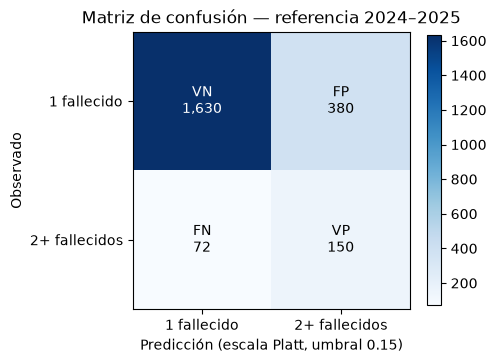

,probability_scale,metric,estimate,ci_2_5,ci_97_5,bootstrap_iterations
7,calibrated,f1_multifatal,0.3989,0.3523,0.4423,1000
8,calibrated,precision_multifatal,0.2830,0.2430,0.3229,1000
9,calibrated,recall_multifatal,0.6757,0.6143,0.7330,1000
10,calibrated,pr_auc,0.3254,0.2703,0.3871,1000
11,calibrated,roc_auc,0.7916,0.7595,0.8227,1000
12,calibrated,brier,0.0777,0.0694,0.0857,1000
13,calibrated,ece_10_bins,0.0133,0.0084,0.0269,1000


In [18]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(
    y_referencia, (p_platt >= umbrales["calibrated"]["value"]).astype(int)
)
fig, ax = plt.subplots(figsize=(5, 4.2))
imagen = ax.imshow(matriz, cmap="Blues")
etiquetas = [["VN", "FP"], ["FN", "VP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{etiquetas[i][j]}\n{matriz[i, j]:,}",
                ha="center", va="center",
                color="white" if matriz[i, j] > matriz.max() / 2 else "black")
ax.set_xticks([0, 1], ["1 fallecido", "2+ fallecidos"])
ax.set_yticks([0, 1], ["1 fallecido", "2+ fallecidos"])
ax.set_xlabel("Predicción (escala Platt, umbral 0.15)")
ax.set_ylabel("Observado")
ax.set_title("Matriz de confusión — referencia 2024–2025")
fig.colorbar(imagen, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

intervalos = pd.read_csv(
    ROOT / "report/tables/final_reference_bootstrap_ci_2024_2025.csv"
)
intervalos[intervalos["probability_scale"] == "calibrated"].round(4)

El mayor recall calibrado (0.676) se obtiene a costa de 380 falsos positivos; con 72 falsos negativos, el modelo no se describe como excelente. Los intervalos bootstrap remuestrean filas con predicciones congeladas: no cubren incertidumbre de entrenamiento, selección, dependencia temporal o espacial, ni generalización futura.

### Capacidad de ordenamiento y calibración

Las curvas separan la capacidad de ordenamiento del punto de decisión; el diagrama de confiabilidad contrasta ambas escalas de probabilidad frente a la diagonal ideal.

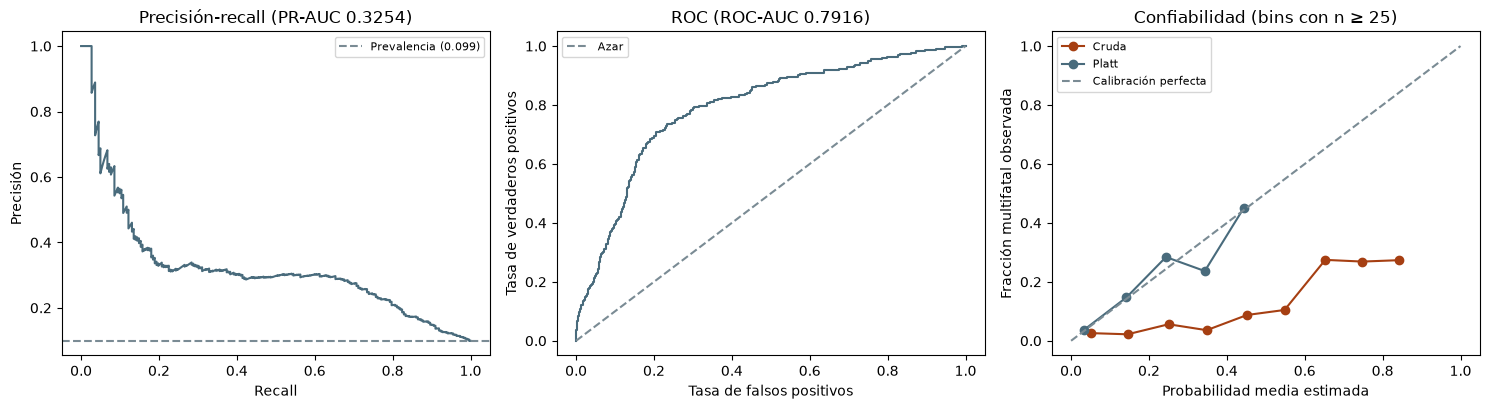

In [19]:
from sklearn.metrics import precision_recall_curve, roc_curve

prevalencia = float(y_referencia.mean())
precision_curva, recall_curva, _ = precision_recall_curve(y_referencia, p_cruda)
fpr, tpr, _ = roc_curve(y_referencia, p_cruda)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(recall_curva, precision_curva, color=COLOR_BASE)
axes[0].axhline(prevalencia, color="#7A8B94", linestyle="--",
                label=f"Prevalencia ({prevalencia:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precisión")
axes[0].set_title(f"Precisión-recall (PR-AUC {almacenadas['raw']['pr_auc']:.4f})")
axes[0].legend(fontsize=8)

axes[1].plot(fpr, tpr, color=COLOR_BASE)
axes[1].plot([0, 1], [0, 1], color="#7A8B94", linestyle="--", label="Azar")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title(f"ROC (ROC-AUC {almacenadas['raw']['roc_auc']:.4f})")
axes[1].legend(fontsize=8)

bordes = np.linspace(0, 1, 11)
for probabilidades, color, etiqueta in [
    (p_cruda, COLOR_ACENTO, "Cruda"),
    (p_platt, COLOR_BASE, "Platt"),
]:
    centros, observados = [], []
    for inferior, superior in zip(bordes[:-1], bordes[1:]):
        mascara = (probabilidades >= inferior) & (
            (probabilidades < superior) if superior < 1 else (probabilidades <= superior)
        )
        if mascara.sum() >= 25:
            centros.append(float(probabilidades[mascara].mean()))
            observados.append(float(y_referencia[mascara].mean()))
    axes[2].plot(centros, observados, marker="o", color=color, label=etiqueta)
axes[2].plot([0, 1], [0, 1], color="#7A8B94", linestyle="--",
             label="Calibración perfecta")
axes[2].set_xlabel("Probabilidad media estimada")
axes[2].set_ylabel("Fracción multifatal observada")
axes[2].set_title("Confiabilidad (bins con n ≥ 25)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

La precisión se mantiene entre tres y cuatro veces la prevalencia en el rango de recall 0.2–0.7, pero nunca alcanza valores altos. La escala cruda queda sistemáticamente por debajo de la diagonal, es decir, es optimista; tras Platt los bins con soporte suficiente se alinean con la diagonal.

### Valor del ordenamiento

La curva de ganancia acumulada traduce la capacidad de ordenar en términos operativos: qué fracción de los siniestros multifatales se recupera al revisar los casos con mayor probabilidad estimada.

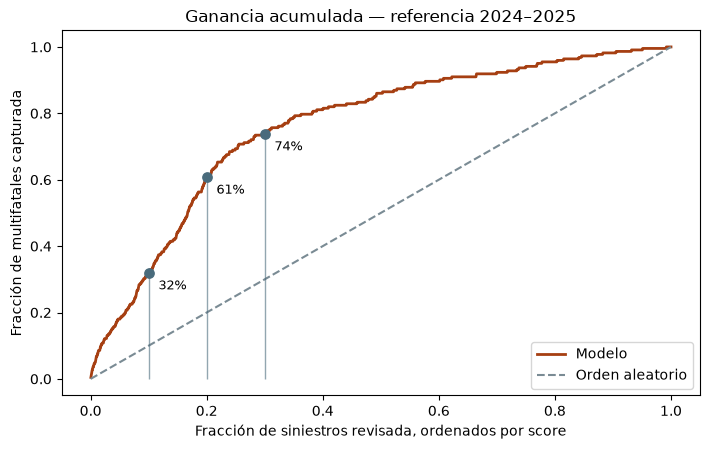

Revisando el 10% de mayor score se recupera 32.0% de los multifatales
Revisando el 20% de mayor score se recupera 60.8% de los multifatales
Revisando el 30% de mayor score se recupera 73.9% de los multifatales


In [20]:
orden = np.argsort(-p_platt)
capturado = np.cumsum(y_referencia[orden]) / y_referencia.sum()
revisado = np.arange(1, len(y_referencia) + 1) / len(y_referencia)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(revisado, capturado, color=COLOR_ACENTO, linewidth=2, label="Modelo")
ax.plot([0, 1], [0, 1], color="#7A8B94", linestyle="--", label="Orden aleatorio")
for marca in (0.10, 0.20, 0.30):
    valor = float(np.interp(marca, revisado, capturado))
    ax.vlines(marca, 0, valor, color=COLOR_BASE, linewidth=1, alpha=0.6)
    ax.scatter([marca], [valor], s=45, color=COLOR_BASE, zorder=5)
    ax.annotate(f"{valor * 100:.0f}%", (marca, valor), textcoords="offset points",
                xytext=(7, -12), fontsize=9)
ax.set_xlabel("Fracción de siniestros revisada, ordenados por score")
ax.set_ylabel("Fracción de multifatales capturada")
ax.set_title("Ganancia acumulada — referencia 2024–2025")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

for marca in (0.10, 0.20, 0.30):
    print(f"Revisando el {marca:.0%} de mayor score se recupera "
          f"{np.interp(marca, revisado, capturado):.1%} de los multifatales")

Revisando el 20 % de los siniestros con mayor probabilidad se recupera cerca del 61 % de los multifatales, frente al 20 % que recuperaría una revisión en orden aleatorio. Esa es la expresión más directa del valor del modelo: no clasifica con precisión alta, pero ordena de forma útil.

### Comparación con líneas base

Las líneas base comparten el mismo contrato de variables, la misma política de umbral y la misma referencia. El bootstrap pareado inspecciona seis comparaciones con IC 95 % nominales, sin ajuste por multiplicidad.

In [21]:
lineas_base = pd.read_csv(
    ROOT / "report/tables/final_reference_baseline_comparison_2024_2025.csv"
)
pareado = pd.read_csv(ROOT / "report/tables/final_paired_bootstrap_2024_2025.csv")
print("Desempeño descriptivo en la referencia:")
display(
    lineas_base[["model", "probability_scale", "threshold", "f1_multifatal",
                 "precision_multifatal", "recall_multifatal", "pr_auc",
                 "roc_auc", "brier"]].round(4)
)
print("Bootstrap pareado (diferencias MLP menos línea base):")
pareado[["baseline", "metric", "delta_mlp_minus_baseline", "delta_ci95_low",
         "delta_ci95_high", "nominal_significant_at_5pct"]].round(4)

Desempeño descriptivo en la referencia:


,model,probability_scale,threshold,f1_multifatal,precision_multifatal,recall_multifatal,pr_auc,roc_auc,brier
0,MLP_definitiva,raw,0.65,0.4030,0.3025,0.6036,0.3254,0.7916,0.1642
1,MLP_definitiva,platt,0.15,0.3989,0.2830,0.6757,0.3254,0.7916,0.0777
2,DummyClassifier_prior,raw,0.10,0.1809,0.0995,1.0000,0.0995,0.5000,0.0896
3,LogisticRegression_balanced,raw,0.65,0.3733,0.2850,0.5405,0.2848,0.7780,0.1671
4,RandomForest_balanced,raw,0.35,0.3778,0.2673,0.6441,0.3156,0.7882,0.0979


Bootstrap pareado (diferencias MLP menos línea base):


,baseline,metric,delta_mlp_minus_baseline,delta_ci95_low,delta_ci95_high,nominal_significant_at_5pct
0,LogisticRegression_balanced,pr_auc,0.0406,0.0111,0.0709,True
1,LogisticRegression_balanced,roc_auc,0.0136,0.0038,0.0238,True
2,LogisticRegression_balanced,f1_multifatal,0.0298,0.0034,0.0576,True
3,RandomForest_balanced,pr_auc,0.0098,-0.0256,0.0407,False
4,RandomForest_balanced,roc_auc,0.0035,-0.0085,0.0149,False
5,RandomForest_balanced,f1_multifatal,0.0252,0.0017,0.0479,True


La MLP supera nominalmente a la regresión logística en PR-AUC, ROC-AUC y F1. Frente a Random Forest, los intervalos de PR-AUC y ROC-AUC incluyen cero; F1 es la excepción nominal (+0.0252, IC 95 % [0.0017, 0.0479]). La evidencia es condicional a predicciones congeladas y no establece superioridad universal.

## 11. Explicabilidad con Gradient SHAP

Gradient SHAP usa fondo 2021–2022 y ejemplos de 2023, sin filas ni etiquetas de la referencia. La importancia se agrupa por variable cruda y la estabilidad se verifica en tres muestras y semillas deterministas (correlación de rangos Spearman mínima 0.9897); se interpretan bandas de importancia, no el orden exacto, y la lectura es asociativa, no causal.

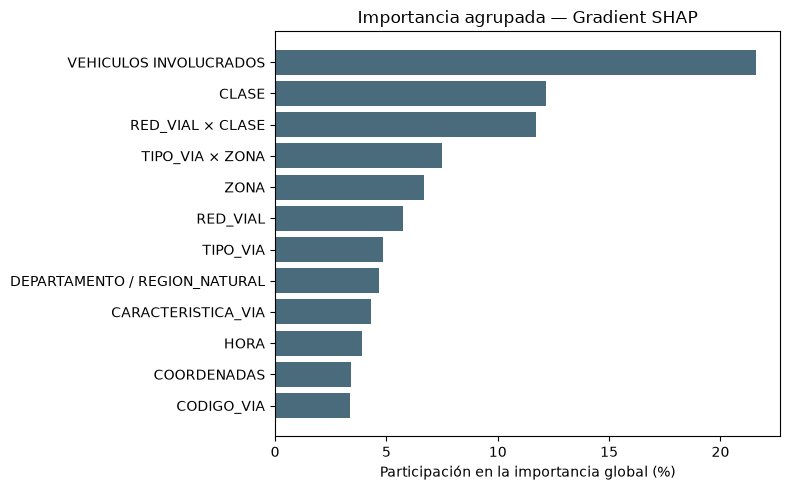

,raw_variable_group,rank_median,rank_range,stability_tier
0,VEHICULOS INVOLUCRADOS,1,0,stable_top
1,CLASE,2,0,stable_top
2,RED_VIAL × CLASE,3,0,stable_top
3,TIPO_VIA × ZONA,4,0,stable_top
4,ZONA,5,0,stable_top
5,RED_VIAL,6,0,stable_band
6,DEPARTAMENTO / REGION_NATURAL,7,1,stable_band
7,CARACTERISTICA_VIA,8,1,stable_band
8,TIPO_VIA,9,2,stable_band
9,HORA,10,1,stable_band


In [22]:
importancia = pd.read_csv(
    ROOT / "report/tables/final_explainability_group_importance.csv"
)
estabilidad = pd.read_csv(
    ROOT / "report/tables/final_explainability_stability.csv"
)

top = importancia.nsmallest(12, "rank").sort_values("rank", ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["raw_variable_group"], 100 * top["importance_share"],
        color=COLOR_BASE)
ax.set_xlabel("Participación en la importancia global (%)")
ax.set_title("Importancia agrupada — Gradient SHAP")
plt.tight_layout()
plt.show()

estabilidad[["raw_variable_group", "rank_median", "rank_range",
             "stability_tier"]].head(12)

## 12. Diagnósticos rolling internos

Dos folds rolling usan exclusivamente fechas anteriores a 2024; dentro de cada fold, las ventanas de ajuste, comparación, calibración y evaluación externa son cronológicas y disjuntas. Son diagnósticos de variabilidad interna, no un test externo.

In [23]:
roles = pd.read_csv(ROOT / "report/tables/temporal_nested_fold_roles.csv")
metricas_outer = pd.read_csv(
    ROOT / "report/tables/temporal_nested_outer_metrics.csv"
)
print("Roles cronológicos por fold:")
display(roles)
print("Métricas de las ventanas outer:")
metricas_outer.round(4)

Roles cronológicos por fold:


,fold,role,date_min,date_max,n,positives
0,rolling_1,fit,2021-01-01,2021-06-30,1176,112
1,rolling_1,selection,2021-07-01,2021-12-31,1216,120
2,rolling_1,calibration,2022-01-01,2022-06-30,1239,137
3,rolling_1,outer,2022-07-01,2022-12-31,1241,141
4,rolling_2,fit,2021-01-01,2021-12-31,2392,232
5,rolling_2,selection,2022-01-01,2022-06-30,1239,137
6,rolling_2,calibration,2022-07-01,2022-12-31,1241,141
7,rolling_2,outer,2023-01-01,2023-12-31,2000,196


Métricas de las ventanas outer:


,fold,config_id,seed,calibration_method,calibrated_threshold,f1_multifatal,precision_multifatal,recall_multifatal,pr_auc,roc_auc
0,rolling_1,MLP_32_16,42,platt,0.20,0.3960,0.3042,0.5674,0.3459,0.7961
1,rolling_2,MLP_32,42,platt,0.15,0.3677,0.2482,0.7092,0.3259,0.8090


## 13. Conclusiones y límites

- Se construyó una única MLP 169–64–32–1 con 12 993 parámetros y técnicas de regularización efectivamente ejecutadas (L2, dropout, pesos de clase, early stopping y ReduceLROnPlateau durante la selección).
- El protocolo temporal es estricto: selección con 2021/2022, reajuste único en 2021–2022, calibración y umbrales validados en 2023, y una referencia 2024–2025 ya consultada que solo se describe.
- La prueba ejecutable del proxy obligó a excluir toda la familia PERSONAS: un resultado menor y válido es preferible a un resultado alto contaminado por el desenlace.
- En la referencia histórica, la red obtiene PR-AUC 0.3254, ROC-AUC 0.7916 y F1 calibrado 0.3989 con excelente calibración (ECE 0.0133). El desempeño es moderado y se reporta sin sobreestimación.
- No existe una cohorte externa o prospectiva intacta: la confirmación independiente requiere datos futuros o externos no observados.